In [13]:
import warnings

In [14]:
warnings.filterwarnings("ignore")

In [15]:
import matplotlib.pyplot as plt

In [16]:
import seaborn as sns

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [9]:
dfheart = pd.read_csv(r"D:\DATASETS\Classification-Datasets\heart.csv")

In [8]:
dfheart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [5]:
dfheart.shape

(1025, 14)

### NaN

In [10]:
dfheart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [11]:
dfheart.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Error Detection

In [12]:
dfheart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<Axes: >

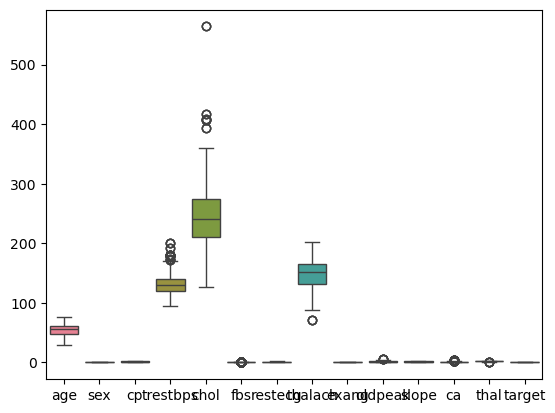

In [17]:
sns.boxplot(dfheart)

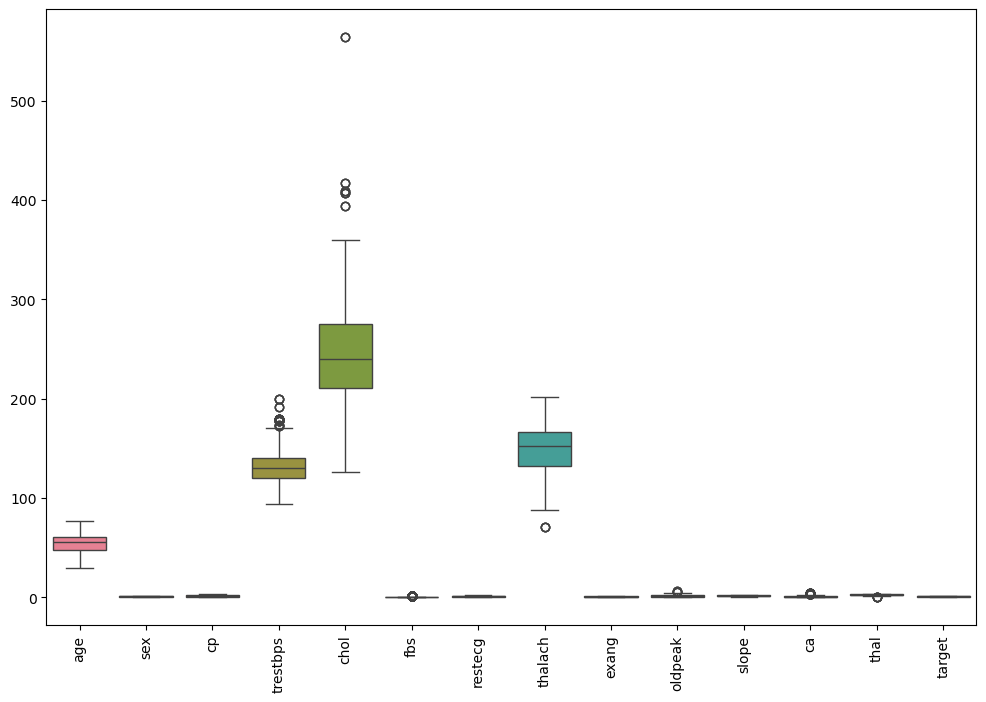

In [19]:
plt.figure(figsize = (12, 8))
sns.boxplot(dfheart)
plt.xticks(rotation = 90)
plt.show()

In [20]:
dfheart.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [21]:
cols = [ 'trestbps', 'chol', 'fbs', 'thalach', 'oldpeak',  'ca', 'thal']

In [22]:
cols

['trestbps', 'chol', 'fbs', 'thalach', 'oldpeak', 'ca', 'thal']

In [23]:
for c in cols : 
    print(dfheart[c])

0       125
1       140
2       145
3       148
4       138
       ... 
1020    140
1021    125
1022    110
1023    110
1024    120
Name: trestbps, Length: 1025, dtype: int64
0       212
1       203
2       174
3       203
4       294
       ... 
1020    221
1021    258
1022    275
1023    254
1024    188
Name: chol, Length: 1025, dtype: int64
0       0
1       1
2       0
3       0
4       1
       ..
1020    0
1021    0
1022    0
1023    0
1024    0
Name: fbs, Length: 1025, dtype: int64
0       168
1       155
2       125
3       161
4       106
       ... 
1020    164
1021    141
1022    118
1023    159
1024    113
Name: thalach, Length: 1025, dtype: int64
0       1.0
1       3.1
2       2.6
3       0.0
4       1.9
       ... 
1020    0.0
1021    2.8
1022    1.0
1023    0.0
1024    1.4
Name: oldpeak, Length: 1025, dtype: float64
0       2
1       0
2       0
3       1
4       3
       ..
1020    0
1021    1
1022    1
1023    0
1024    1
Name: ca, Length: 1025, dtype: int64
0       3

In [24]:
for c in cols :
    q1 = dfheart[c].quantile(0.25)
    q3 = dfheart[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - (1.5 * iqr)
    upper = q3 + (1.5 * iqr)
    dfheart[c] = dfheart[c].map(lambda x : lower if x < lower else  upper if x > upper else x)

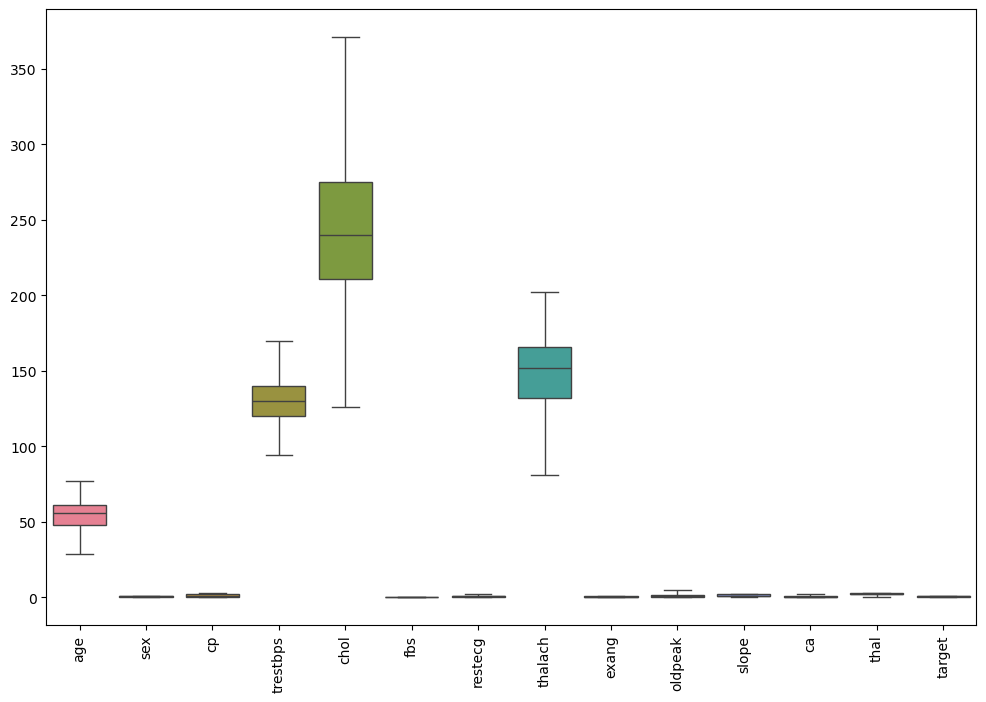

In [25]:
plt.figure(figsize = (12, 8))
sns.boxplot(dfheart)
plt.xticks(rotation = 90)
plt.show()

### Encoding

In [26]:
dfheart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125.0,212.0,0.0,1,168.0,0,1.0,2,2.0,3.0,0
1,53,1,0,140.0,203.0,0.0,0,155.0,1,3.1,0,0.0,3.0,0
2,70,1,0,145.0,174.0,0.0,1,125.0,1,2.6,0,0.0,3.0,0
3,61,1,0,148.0,203.0,0.0,1,161.0,0,0.0,2,1.0,3.0,0
4,62,0,0,138.0,294.0,0.0,1,106.0,0,1.9,1,2.5,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140.0,221.0,0.0,1,164.0,1,0.0,2,0.0,2.0,1
1021,60,1,0,125.0,258.0,0.0,0,141.0,1,2.8,1,1.0,3.0,0
1022,47,1,0,110.0,275.0,0.0,0,118.0,1,1.0,1,1.0,2.0,0
1023,50,0,0,110.0,254.0,0.0,0,159.0,0,0.0,2,0.0,2.0,1


In [27]:
dfheart.dtypes

age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs         float64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object

### Data Separation

In [28]:
dfheart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125.0,212.0,0.0,1,168.0,0,1.0,2,2.0,3.0,0
1,53,1,0,140.0,203.0,0.0,0,155.0,1,3.1,0,0.0,3.0,0
2,70,1,0,145.0,174.0,0.0,1,125.0,1,2.6,0,0.0,3.0,0
3,61,1,0,148.0,203.0,0.0,1,161.0,0,0.0,2,1.0,3.0,0
4,62,0,0,138.0,294.0,0.0,1,106.0,0,1.9,1,2.5,2.0,0


In [29]:
dfheart.drop("target", axis = 1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125.0,212.0,0.0,1,168.0,0,1.0,2,2.0,3.0
1,53,1,0,140.0,203.0,0.0,0,155.0,1,3.1,0,0.0,3.0
2,70,1,0,145.0,174.0,0.0,1,125.0,1,2.6,0,0.0,3.0
3,61,1,0,148.0,203.0,0.0,1,161.0,0,0.0,2,1.0,3.0
4,62,0,0,138.0,294.0,0.0,1,106.0,0,1.9,1,2.5,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140.0,221.0,0.0,1,164.0,1,0.0,2,0.0,2.0
1021,60,1,0,125.0,258.0,0.0,0,141.0,1,2.8,1,1.0,3.0
1022,47,1,0,110.0,275.0,0.0,0,118.0,1,1.0,1,1.0,2.0
1023,50,0,0,110.0,254.0,0.0,0,159.0,0,0.0,2,0.0,2.0


In [31]:
X = dfheart.drop("target", axis = 1)

In [32]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125.0,212.0,0.0,1,168.0,0,1.0,2,2.0,3.0
1,53,1,0,140.0,203.0,0.0,0,155.0,1,3.1,0,0.0,3.0
2,70,1,0,145.0,174.0,0.0,1,125.0,1,2.6,0,0.0,3.0
3,61,1,0,148.0,203.0,0.0,1,161.0,0,0.0,2,1.0,3.0
4,62,0,0,138.0,294.0,0.0,1,106.0,0,1.9,1,2.5,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140.0,221.0,0.0,1,164.0,1,0.0,2,0.0,2.0
1021,60,1,0,125.0,258.0,0.0,0,141.0,1,2.8,1,1.0,3.0
1022,47,1,0,110.0,275.0,0.0,0,118.0,1,1.0,1,1.0,2.0
1023,50,0,0,110.0,254.0,0.0,0,159.0,0,0.0,2,0.0,2.0


In [33]:
y = dfheart["target"]

In [34]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

### Imbalance

In [35]:
y.value_counts()

target
1    526
0    499
Name: count, dtype: int64

<Axes: xlabel='target'>

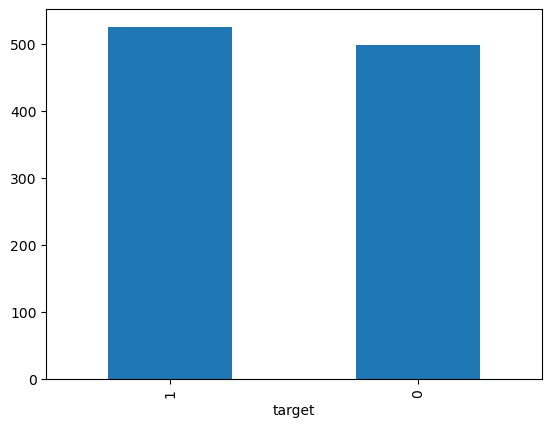

In [36]:
y.value_counts().plot(kind = "bar")

### Data Splitting

In [37]:
from sklearn.model_selection import train_test_split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state= 334)

In [56]:
X.shape

(1025, 13)

In [57]:
X_train.shape

(820, 13)

In [58]:
X_test.shape

(205, 13)

### Model Building

In [59]:
from sklearn.linear_model import LogisticRegression

In [60]:
logreg = LogisticRegression()

In [61]:
logreg

LogisticRegression()

In [62]:
logreg.fit(X_train, y_train)

LogisticRegression()

In [63]:
logreg.score(X_test, y_test)

0.9463414634146341

In [47]:
from sklearn.metrics import accuracy_score

In [48]:
logreg.predict(X_test)

array([0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0])

In [49]:
y_pred = logreg.predict(X_test)

In [50]:
y_pred

array([0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0])

In [51]:
accuracy_score(y_test, y_pred)

0.8682926829268293

## Auto Random State

In [54]:
scorelist = []
for i in range(1000):
    Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.20, random_state=i)
    lrmodel = LogisticRegression()
    lrmodel.fit(Xtrain, ytrain)
    sc = lrmodel.score(Xtest, ytest)
    scorelist.append(sc)

m = max(scorelist)
rs = scorelist.index(m)
print(rs,"==>", m)

334 ==> 0.9463414634146341


In [65]:
X.shape

(1025, 13)

### PCA

In [64]:
from sklearn.decomposition import PCA

In [66]:
pca5 = PCA(n_components= 5)

In [67]:
pca5

PCA(n_components=5)

In [68]:
X_pca5 = pca5.fit_transform(X)

In [69]:
X_pca5.shape

(1025, 5)

In [77]:
X1, X2, y1, y2= train_test_split(X_pca5, y, test_size=0.20, random_state= 334)

In [78]:
X_pca5.shape

(1025, 5)

In [79]:
X1.shape

(820, 5)

In [80]:
X2.shape

(205, 5)

In [81]:
lrmodel1 = LogisticRegression()

In [82]:
lrmodel1.fit(X1, y1)

LogisticRegression()

In [83]:
lrmodel1.score(X2, y2)

0.824390243902439

### PCA Accuracy Score

In [84]:
from sklearn.decomposition import PCA

In [85]:
pca = PCA(0.85)

In [86]:
pca

PCA(n_components=0.85)

In [87]:
X_pca = pca.fit_transform(X)

In [88]:
X_pca.shape

(1025, 2)

In [97]:
X11, X12, y21, y22 = train_test_split(X_pca, y, test_size=0.20, random_state= 334)

In [98]:
X_pca.shape

(1025, 2)

In [99]:
X11.shape

(820, 2)

In [100]:
X12.shape

(205, 2)

In [101]:
lrmodel2 = LogisticRegression()

In [102]:
lrmodel2

LogisticRegression()

In [103]:
lrmodel2.fit(X11, y21)

LogisticRegression()

In [104]:
lrmodel2.score(X12, y22)

0.7268292682926829

In [105]:
slist = []
for i in range(1000):
    train_X, test_X, train_y, test_y = train_test_split(X_pca, y, test_size=0.20, random_state=i)
    lrmodel3 = LogisticRegression()
    lrmodel3.fit(train_X, train_y)
    sc = lrmodel3.score(test_X, test_y)
    slist.append(sc)

m = max(slist)
r = slist.index(m)
print(r,"==>", m)

297 ==> 0.7804878048780488
